# 02 · EDA — Titanic

**Dataset:** `data/titanic_clean.csv` (the original Kaggle file — light cleaning still needed).
**Covers:** univariate EDA · bivariate EDA · correlation · reading a distribution.
**Time yourself:** ~30 minutes.

Most of these have a **number** as the answer and a **sentence** as the real answer.
Say the sentence out loud.

In [13]:
import os
if os.path.basename(os.getcwd()) == 'solutions':
    os.chdir('..')

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = pd.read_csv('data/titanic_clean.csv')
df.columns = df.columns.str.lower()
df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(lambda s: s.fillna(s.median()))
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---

## Part A — Univariate

### Q1. What is the overall survival rate? Is the target balanced?

<details><summary>hint</summary>

`value_counts(normalize=True)` gives proportions. The mean of a 0/1 column is also the rate.

</details>

In [15]:
print(df['survived'].value_counts())
print(df['survived'].value_counts(normalize=True).round(3))

# ~38% survived / 62% died. Mildly imbalanced -- not enough to need SMOTE, but enough
# that a "always predict died" model scores 62% accuracy. That's the number to beat.

survived
0    549
1    342
Name: count, dtype: int64
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


### Q2. Plot `age` and `fare`: histogram + boxplot side by side for each. Print the skew of
both. Which one is heavily skewed, and what would you do about it?

<details><summary>hint</summary>

`plt.subplots(2, 2)` then index `axes[row, col]`. Skew above ~1 in absolute value is the usual 'this is skewed' threshold.

</details>

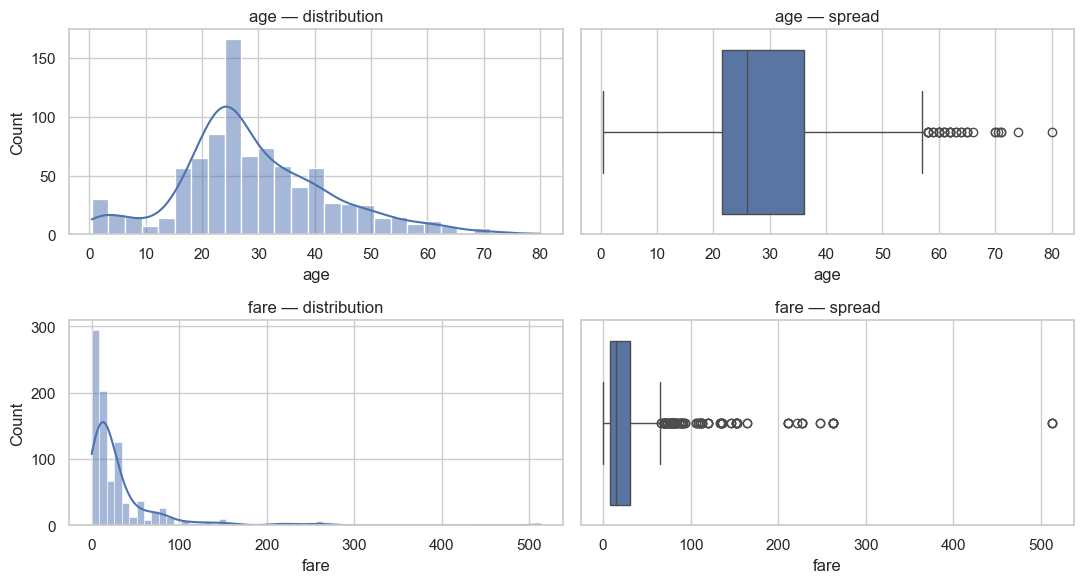

age     0.53
fare    4.79
dtype: float64


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for i, col in enumerate(['age', 'fare']):
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} — distribution')
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} — spread')
plt.tight_layout()
plt.show()

print(df[['age', 'fare']].skew().round(2))

# age  ~0.5  -> roughly symmetric, mean is a fine summary
# fare ~4.8  -> heavily right-skewed; use the median, and log-transform it for any
#               distance- or scale-sensitive model.

### Q3. Show the distribution of `pclass`, `sex` and `embarked` as proportions. Any class that is rare enough to worry about?

<details><summary>hint</summary>

Loop over the columns rather than writing three near-identical blocks.

</details>

pclass
3    0.551
1    0.242
2    0.207 

sex
male      0.648
female    0.352 

embarked
S    0.725
C    0.189
Q    0.086 



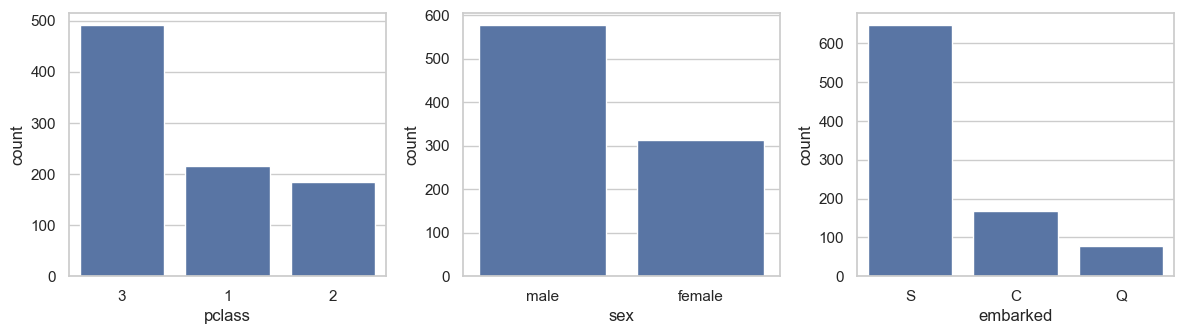

In [17]:
for col in ['pclass', 'sex', 'embarked']:
    print(df[col].value_counts(normalize=True).round(3).to_string(), '\n')

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, ['pclass', 'sex', 'embarked']):
    sns.countplot(data=df, x=col, ax=ax, order=df[col].value_counts().index)
plt.tight_layout()
plt.show()

# embarked='Q' is only ~9% -- small, but big enough to keep as its own level.

---

## Part B — Bivariate: what predicts survival?

### Q4. What is the survival rate by `sex`? By `pclass`? Give counts alongside the rates — a rate on 5 rows is not a finding.

<details><summary>hint</summary>

`.agg(n='count', rate='mean')` names both aggregations in one call.

</details>

In [18]:
for col in ['sex', 'pclass']:
    print(df.groupby(col)['survived'].agg(n='count', rate='mean').round(3), '\n')

# sex is brutal: ~74% of women survived vs ~19% of men.
# pclass is monotonic: 63% / 47% / 24% from 1st to 3rd.

          n   rate
sex               
female  314  0.742
male    577  0.189 

          n   rate
pclass            
1       216  0.630
2       184  0.473
3       491  0.242 



### Q5. Now cross `sex` **and** `pclass` together. Present it as a 2×3 table of survival
rates. What does 3rd-class male vs 1st-class female tell you?

<details><summary>hint</summary>

`pivot_table` with `aggfunc='mean'` on a 0/1 column gives you a rate table directly. `sns.heatmap(..., annot=True)` makes it readable instantly.

</details>

pclass,1,2,3
sex,,,
female,0.968,0.921,0.500
male,0.369,0.157,0.135


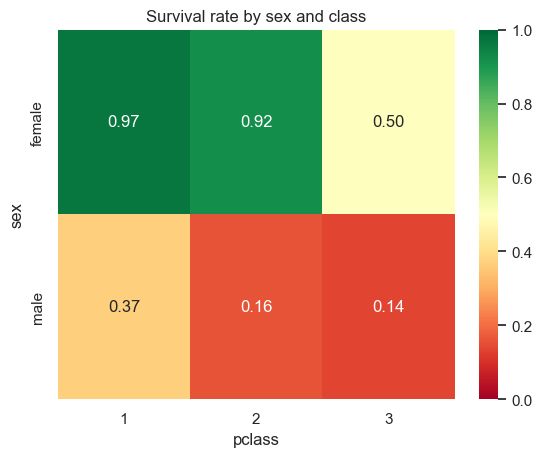

In [19]:
pivot = df.pivot_table(index='sex', columns='pclass', values='survived', aggfunc='mean')
display(pivot.round(3))

sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1)
plt.title('Survival rate by sex and class')
plt.show()

# ~97% of 1st-class women survived vs ~14% of 3rd-class men -- a 7x gap. "Women and
# children first" was applied, but class gated access to the boats on top of it.

### Q6. Does `age` differ between survivors and non-survivors? Show it two ways (a boxplot
and overlaid distributions), and back it up with a number.

<details><summary>hint</summary>

`hue='survived'` on a histplot overlays the two groups.

</details>

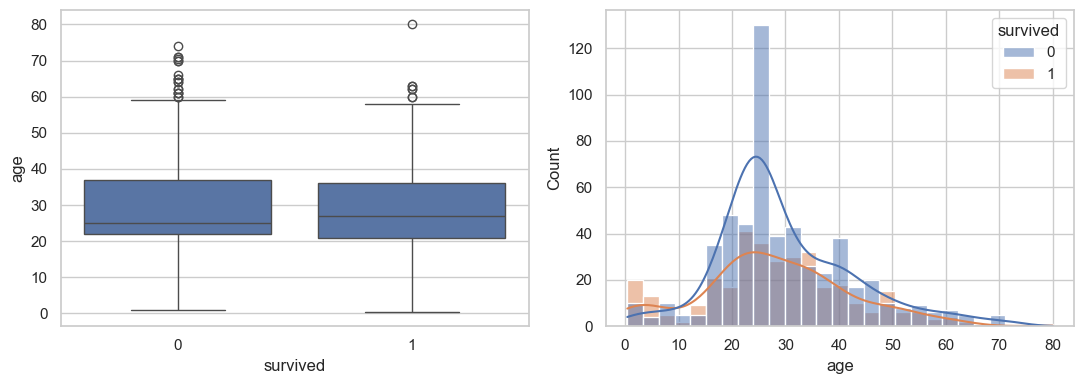

           mean  median  count
survived                      
0         29.74    25.0    549
1         28.11    27.0    342


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x='survived', y='age', ax=axes[0])
sns.histplot(data=df, x='age', hue='survived', kde=True, ax=axes[1])
plt.tight_layout()
plt.show()

print(df.groupby('survived')['age'].agg(['mean', 'median', 'count']).round(2))

# The medians are almost identical -- age on its own barely separates the classes.
# The one visible bump is at the very low end: young children survived more.

### Q7. Age looked flat overall — but that can hide a non-linear effect. Bin age into
`child / teen / adult / senior` and compute the survival rate per bin.
Did binning reveal something the mean hid?

<details><summary>hint</summary>

`pd.cut` with explicit `bins` and `labels`. Pass `observed=True` to groupby on a categorical to avoid empty-group rows.

</details>

,n,rate
age_group,,
child,69,0.580
teen,70,0.429
adult,730,0.366
senior,22,0.227


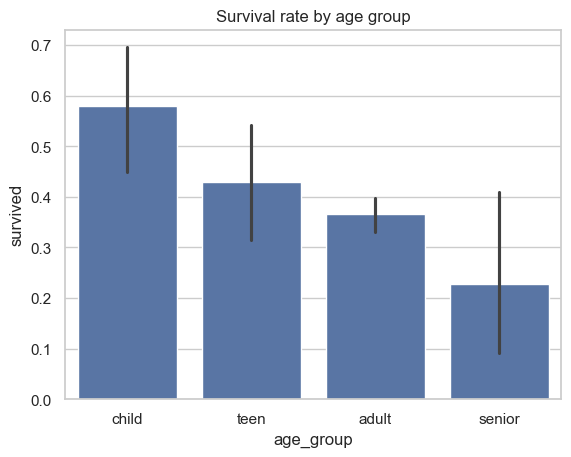

In [21]:
df['age_group'] = pd.cut(df['age'], bins=[0, 12, 18, 60, 100],
                         labels=['child', 'teen', 'adult', 'senior'])
rates = df.groupby('age_group', observed=True)['survived'].agg(n='count', rate='mean')
display(rates.round(3))

sns.barplot(data=df, x='age_group', y='survived')
plt.title('Survival rate by age group')
plt.show()

# Yes: child 58%, teen 43%, adult 37%, senior 23%. The ordering is monotonic, but the
# EFFECT IS NOT LINEAR IN AGE -- it's essentially a step at childhood. The 18-60 adult
# band holds most of the passengers and is almost flat, so that flat majority drags the
# Pearson correlation to ~ -0.06 while the real signal (being a child) sits in a narrow
# 12-year window. The mean hid it; the bins expose it.

### Q8. Cross `embarked` with `pclass` as row-normalised proportions. Does `embarked` actually carry its own signal, or is it a proxy for something else?

<details><summary>hint</summary>

`pd.crosstab(..., normalize='index')` makes each row sum to 1, which is what you want when the row totals differ a lot.

</details>

In [22]:
ct = pd.crosstab(df['embarked'], df['pclass'], normalize='index')
display(ct.round(3))
print(df.groupby('embarked')['survived'].agg(n='count', rate='mean').round(3))

# Cherbourg passengers survived most (~55%) -- but ~50% of them were 1st class, vs ~20%
# at Southampton. Most of embarked's apparent effect is class leaking through it.

pclass,1,2,3
embarked,,,
C,0.506,0.101,0.393
Q,0.026,0.039,0.935
S,0.200,0.254,0.546


            n   rate
embarked            
C         168  0.554
Q          77  0.390
S         646  0.339


---

## Part C — Correlation

### Q9. Build a correlation heatmap of the numeric columns. Note any pair above |0.5| —
you'll need this in notebook 03.

<details><summary>hint</summary>

`select_dtypes(include='number')` picks the numeric columns. Drop the ID — its correlation with anything is meaningless.

</details>

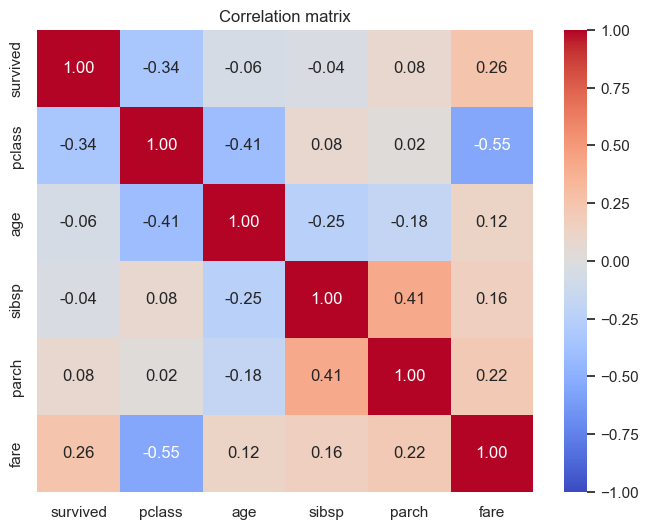

In [23]:
num = df.select_dtypes(include='number').drop(columns=['passengerid'])
corr = num.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix')
plt.show()

# pclass vs fare ~ -0.55 (1st class costs more) -- the pair to watch for collinearity.
# sibsp vs parch ~  0.41 (both count family aboard) -- candidates to merge.

### Q10. `sex` is the single strongest predictor here, but it doesn't appear in your heatmap.
Why not? Fix it, and report the correlation between `sex` and `survived`.

<details><summary>hint</summary>

What does `.corr()` do with an object column? It skips it, without telling you.

</details>

In [24]:
# It's an object column, and .corr() silently ignores non-numeric columns.
df['sex_male'] = (df['sex'] == 'male').astype(int)
print(df[['sex_male', 'survived']].corr().round(3))

# ~ -0.54 -- the strongest single correlate of survival in the dataset, and it was
# invisible until it was encoded. Never read a heatmap as "these are all my features".

          sex_male  survived
sex_male     1.000    -0.543
survived    -0.543     1.000


### Q11. `age` has a near-zero correlation with `survived`. Argue why dropping it on that
basis would be a mistake. Support your answer with something you computed earlier.

<details><summary>hint</summary>

Look back at your age-group bar chart. Could a single straight line through that shape capture it?

</details>

In [25]:
print(df[['age', 'survived']].corr().round(3))

# Pearson correlation measures only the *linear* part of an association. From Q6 the real
# relationship is a step: children ~58%, then a long flat adult plateau ~37%. A single
# straight line fitted through that is nearly horizontal, so the correlation is ~ -0.06 --
# while `age < 12` remains genuinely predictive, and a tree will find and split on it.
# Never drop a feature on |corr| alone; check a plot or a permutation importance first.
# The general rule: low correlation means "no linear signal", not "no signal".

           age  survived
age       1.00     -0.06
survived -0.06      1.00


---

## Part D — Synthesis

### Q12. Freeform, and this is the one they actually care about. In 3–5 bullets: what are the
strongest drivers of survival, what feature would you engineer next, and what is
the one thing in this data you distrust?

<details><summary>hint</summary>

An interviewer asking this is testing whether you can turn plots into decisions.

</details>

In [ ]:
# - sex dominates: ~74% of women survived vs ~19% of men (corr -0.54 once encoded).
# - pclass is second and monotonic (63/47/24%), and it interacts with sex rather than
#   just adding to it: 1st-class women ~97%, 3rd-class men ~14%.
# - age matters only non-linearly -- children ~58% vs an adult plateau ~37%, so the
#   linear correlation is ~ -0.06 and hides a real effect.
# - Next feature: family_size = sibsp + parch + 1, plus is_alone. sibsp and parch are
#   correlated (0.41) and each is a weak half of the same idea. Also `title` from the
#   name (Mr/Mrs/Miss/Master), which encodes sex, age bracket and status in one column.
# - What I distrust: `fare` is per *ticket*, not per person -- a family of 5 on one ticket
#   shows the same fare five times, so it partly encodes group size, not wealth.
#   Dividing by the ticket's passenger count would be the honest version.